In [1]:
import numpy as np
import pandas as pd
import itertools
from anastruct import SystemElements

In [2]:
# variables 
# theta = sp.symbols('theta') # angle of the beam in respect to horizon
# L_h,m_p,g = sp.symbols ('L_h,m_p,g') # Half length, m_p is platform mass, g is gravity 
# rho_ai = sp.symbols('rho_ai') # density of aluminium 
# V_p = sp.symbols ('V_p') # volume of the platform
# A = sp.symbols('A') # cross-sectional area of the beam
# I = sp.symbols('I') # moment of inertia of the beam


def Pin_locator (theta_deg, L, pin_name=None):
   

    theta = np.radians(theta_deg)   # Convert degrees to radians
    x = L*np.cos(theta)
    y = L*np.sin(theta)
    L_h=L/2
    x_h = L_h*np.cos(theta)
    y_h = L_h*np.sin(theta)

    H = np.array([0, L]).astype(float)  
    A = H + np.array([0, -y]).astype(float)  
    P1 = H + np.array([x_h, -y_h]).astype(float)  
    B = A + np.array([x, y]).astype(float)  
    C = H + np.array([x, -y]).astype(float)  
    P2 = B + np.array([x_h, -y_h]).astype(float)  
    E = B + np.array([x, -y]).astype(float)  
    D = C + np.array([x, y]).astype(float)  
    P3 = E + np.array([x_h, y_h]).astype(float)  
    F = E + np.array([x, y]).astype(float)  
    G = D + np.array([x, -y]).astype(float)  
    
    # Dictionary of all pins
    pins_dict = {'H': H, 'A': A, 'P1': P1, 'B': B, 'C': C, 'P2': P2, 
                 'E': E, 'D': D, 'P3': P3, 'F': F, 'G': G}
    
    
    if pin_name is None:
        return H, A, P1, B, C, P2, E, D, P3, F, G
    else:
        if pin_name not in pins_dict:
            raise ValueError(f"Pin '{pin_name}' not found. Available pins: {list(pins_dict.keys())}")
        return pins_dict[pin_name]
    


In [ ]:
import numpy as np
import pandas as pd
import itertools
from anastruct import SystemElements

# --- Constants ---
E_al = 70e9        
rho_al = 2700     
g = 9.81

def run_doe_simulation(theta_deg, L, A_cs, I_val, Px_dist):
    """
    Returns the max tension and compression for a specific set of parameters.
    """
    # 1. Setup system and weights
    weight_per_meter = rho_al * A_cs * g
    ss = SystemElements(EA=float(E_al * A_cs), EI=float(E_al * I_val))
    
    # 2. Get Coordinates (Assuming Pin_locator is defined elsewhere in your script)
    pin_names = ['H', 'A', 'P1', 'B', 'C', 'P2', 'E', 'D']
    coords = {name: Pin_locator(theta_deg, L, pin_name=name) for name in pin_names}
    
    # 3. Connectivity
    elements = [
        ('H', 'P1'), ('P1', 'C'), ('A', 'P1'), ('P1', 'B'), 
        ('B', 'P2'), ('P2', 'E'), ('C', 'P2'), ('P2', 'D'), 
        ('E', 'D')                                         
    ]

    # 4. Build Structure
    for n1, n2 in elements:
        ss.add_element(location=[coords[n1], coords[n2]], g=float(weight_per_meter))
    
    # 5. Boundary Conditions
    id_H = ss.find_node_id(coords['H'])
    id_A = ss.find_node_id(coords['A'])
    ss.add_support_hinged(node_id=id_H)
    ss.add_support_hinged(node_id=id_A)

    # 6. Apply Distributed Load (on the top member E-D)
    # Finding the element ID for ('E', 'D') - it's the last one added (ID 9)
    ss.q_load(element_id=9, q=Px_dist)
    
    # 7. Solve
    ss.solve()
# --- 8. Extract Results (Corrected Logic) ---
    axial_forces = np.array(ss.get_element_result_range('axial'))
    
    # Tension: Max positive value (if none, then 0)
    raw_max = np.max(axial_forces)
    peak_force = raw_max if raw_max > 0 else 0
    

    
    return peak_force


# --- Define DOE Parameter Ranges ---
Range = 20

factors = {
    'theta': np.linspace(5, 45, num=Range),          # Degrees
    'L': np.linspace(0.120, 0.700, num=Range),      # Offset in meters
    'A_cs': np.linspace(0.0002, 0.010, num=Range),  # Area in m^2 (Fixed [] to ())
    'I': np.linspace(2e-6, 5e-5, num=Range)         # Moment of Inertia (Fixed [] to ())
}

fixed_q = -4.9  # N/m (your fixed distributed load)

# --- Run the Experiment ---
results = []

# itertools.product creates the full factorial combination
for t, l_val, a, i in itertools.product(*factors.values()):
    max_t = run_doe_simulation(t, l_val, a, i, fixed_q)
    
    results.append({
        'Theta': t,
        'L_Offset': l_val,
        'Area': a,
        'Inertia': i,
        'Max_Force': max_t,

    })

# --- Convert to DataFrame ---
df = pd.DataFrame(results)

print(df.head()) # Preview the first 5 rows

   Theta  L_Offset    Area   Inertia  Max_Force
0    5.0      0.12  0.0002  0.000002  30.352323
1    5.0      0.12  0.0002  0.000005  30.350620
2    5.0      0.12  0.0002  0.000007  30.349142
3    5.0      0.12  0.0002  0.000010  30.347846
4    5.0      0.12  0.0002  0.000012  30.346701


In [4]:
df.to_csv('Dynamics Data')

In [5]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. ANOVA for Maximum Tension ---
# We use ordinary least squares to fit the model
model_tens = ols('Max_Force ~ C(Theta) + C(L_Offset) + C(Area) + C(Inertia)', data=df).fit()
anova_tens = sm.stats.anova_lm(model_tens, typ=2)

print("--- ANOVA Results (Tension) ---")
print(anova_tens)


--- ANOVA Results (Tension) ---
                   sum_sq        df             F  PR(>F)
C(Theta)     5.528236e+10      19.0  11958.373347     0.0
C(L_Offset)  1.898341e+10      19.0   4106.386310     0.0
C(Area)      3.499038e+10      19.0   7568.923806     0.0
C(Inertia)   1.980107e+02      19.0      0.000043     1.0
Residual     3.891095e+10  159923.0           NaN     NaN


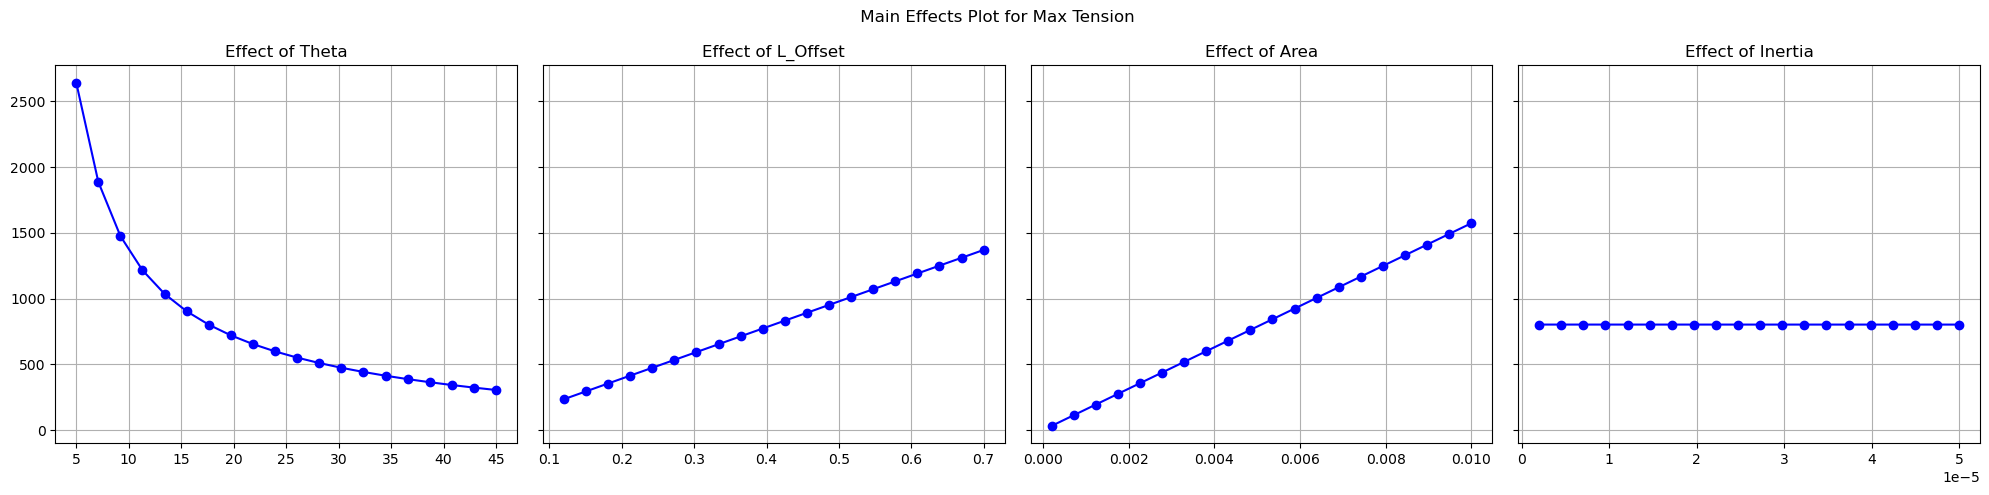

In [8]:
# --- 4. Main Effects Logic ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
factors_to_plot = ['Theta', 'L_Offset', 'Area', 'Inertia']

for i, col in enumerate(factors_to_plot):
    # Group by the factor and find the mean tension at each level
    main_effect = df.groupby(col)['Max_Force'].mean()
    axes[i].plot(main_effect.index, main_effect.values, marker='o', linestyle='-', color='b')
    axes[i].set_title(f'Effect of {col}')
    axes[i].grid(True)

plt.suptitle(" Main Effects Plot for Max Tension")
plt.tight_layout()
plt.show()

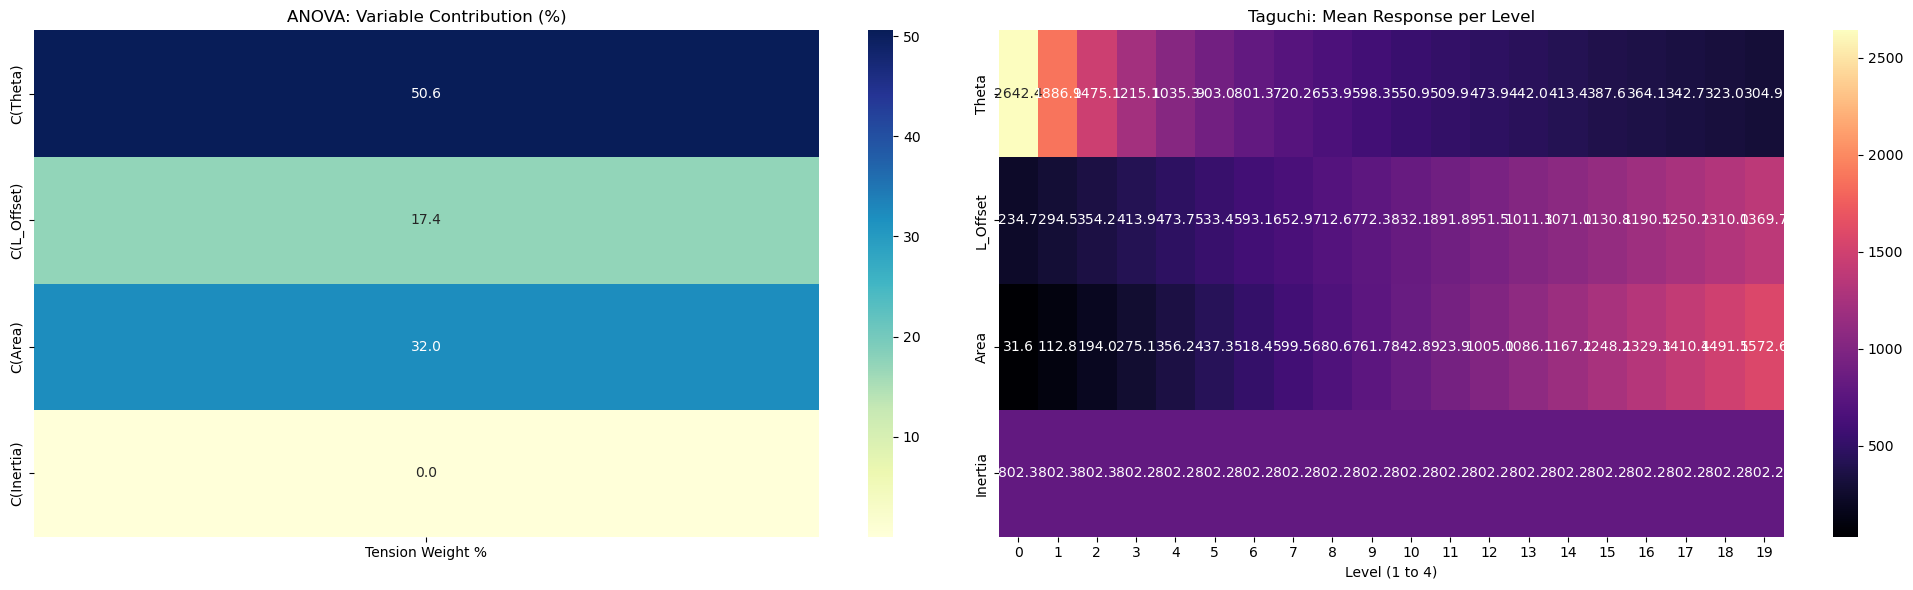

In [ ]:


# --- 1. ANOVA Heatmap (Weight %) ---
# Calculate Sum of Squares to determine "Weight"
def get_weights(response, data):
    model = ols(f'{response} ~ C(Theta) + C(L_Offset) + C(Area) + C(Inertia)', data=data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    ss = anova_table['sum_sq'].drop('Residual')
    return (ss / ss.sum()) * 100

weights_tens = get_weights('Max_Force', df)
weight_df = pd.DataFrame({'Tension Weight %': weights_tens})

# --- 2. Taguchi Response Heatmap ---
# Showing Mean Tension for each level of each factor
taguchi_data = {}
for col in ['Theta', 'L_Offset', 'Area', 'Inertia']:
    taguchi_data[col] = df.groupby(col)['Max_Force'].mean().values
taguchi_df = pd.DataFrame(taguchi_data).T

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# A. ANOVA Weight Heatmap
sns.heatmap(weight_df, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("ANOVA: Variable Contribution (%)")

# B. Taguchi Response Heatmap
sns.heatmap(taguchi_df, annot=True, fmt=".1f", cmap="magma", ax=axes[1])
axes[1].set_title("Taguchi: Mean Response per Level")
axes[1].set_xlabel("Level (1 to 4)")



plt.tight_layout()
plt.show()